In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import timm
from torchvision import models

class FusionModel(nn.Module):

    def __init__(self):

        super(FusionModel, self).__init__()

        self.resnet = models.resnet50(pretrained=True)
        self.resnet.fc = nn.Identity()

        self.vit = timm.create_model(
            "vit_small_patch16_224",
            pretrained=True,
            num_classes=0
        )

        self.fusion = nn.Sequential(
            nn.Linear(2048 + 384, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(),

            nn.Linear(128, 34)
        )

    def forward(self, x):

        resnet_features = self.resnet(x)
        vit_features = self.vit(x)

        combined = torch.cat((resnet_features, vit_features), dim=1)

        return self.fusion(combined)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FusionModel().to(device)

model.load_state_dict(
    torch.load("/content/drive/MyDrive/Dataset/fusion_model.pth")
)

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 48.8MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

FusionModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [7]:
!unzip "/content/drive/MyDrive/Dataset/kurdish_sign_dataset.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1387.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1388.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1389.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1390.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1391.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1392.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1393.JPG  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1394.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1395.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1396.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1397.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1398.jpg  
  inflating: /content/kurdish_sign_dataset/class_6/class_6_1399.jpg  
  inflating: /content/kurdish_sign_data

In [8]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

dataset = datasets.ImageFolder(
    root="/content/kurdish_sign_dataset",
    transform=transform
)

val_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False
)

In [9]:
import numpy as np

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [10]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       0.98      0.99      0.99      1374
           2       0.99      1.00      1.00      1600
           3       0.99      0.99      0.99      1507
           4       0.99      1.00      0.99      2114
           5       0.99      1.00      0.99      1929
           6       0.94      0.99      0.97      1955
           7       0.99      0.91      0.95      1705
           8       1.00      0.99      1.00      1790
           9       1.00      0.99      0.99      1765
          10       0.99      0.99      0.99      1700
          11       1.00      0.99      1.00      1672
          12       0.98      0.99      0.98      1592
          13       0.99      1.00      1.00      1371
          14       1.00      1.00      1.00      3000
          15       1.00      1.00      1.00      3000
          16       1.00      1.00      1.00      3000
          17       1.00    

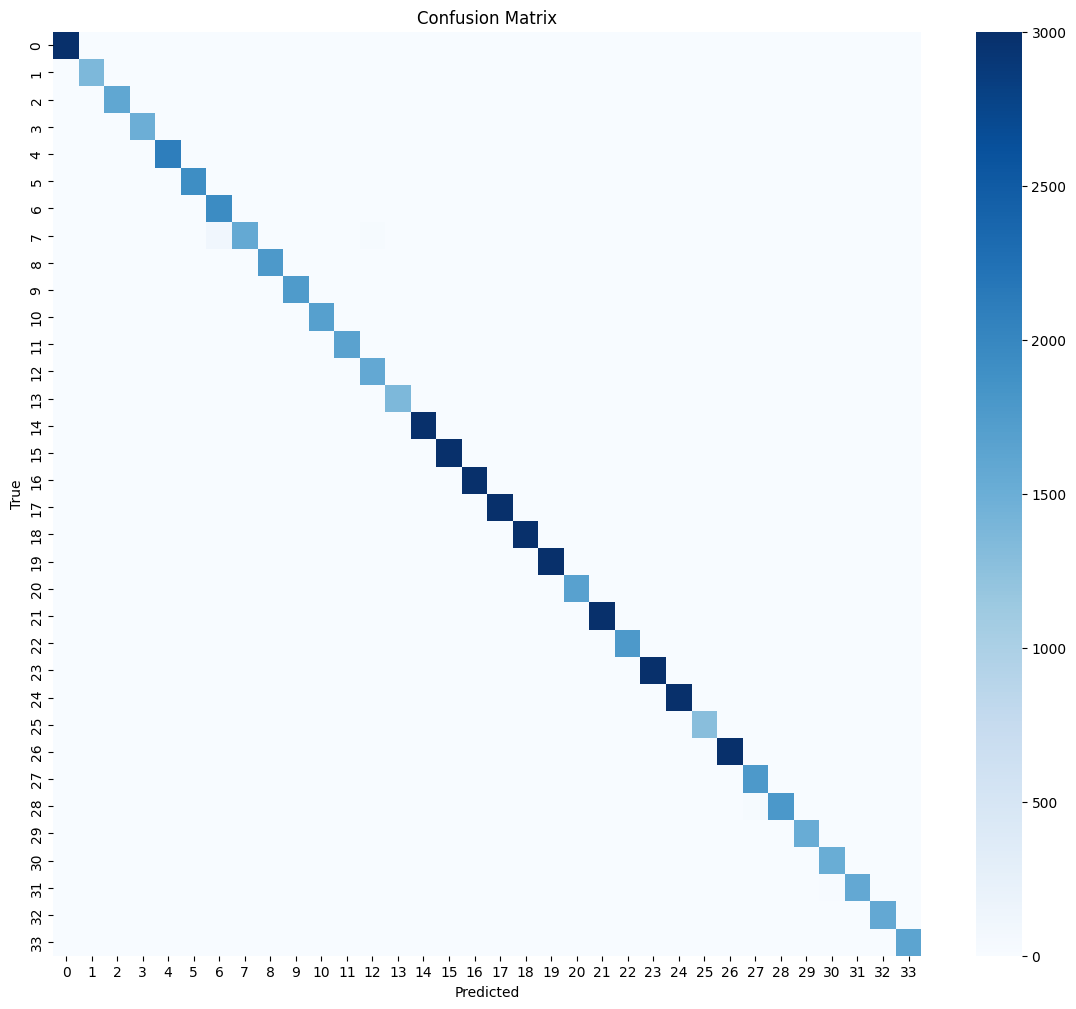

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [12]:
accuracy = np.mean(np.array(y_true) == np.array(y_pred))

with open("evaluation_report.txt", "w") as f:
    f.write("Accuracy: " + str(accuracy) + "\n\n")
    f.write(report)

In [14]:
import numpy as np
from sklearn.metrics import classification_report

accuracy = np.mean(np.array(y_true) == np.array(y_pred))

report = classification_report(y_true, y_pred)

file_path = "/content/drive/MyDrive/Dataset/evaluation_report.txt"

with open(file_path, "w") as f:
    f.write("Kurdish Sign Language Recognition Evaluation\n\n")
    f.write("Final Accuracy: " + str(accuracy) + "\n\n")
    f.write(report)

print("Report saved at:", file_path)

Report saved at: /content/drive/MyDrive/Dataset/evaluation_report.txt


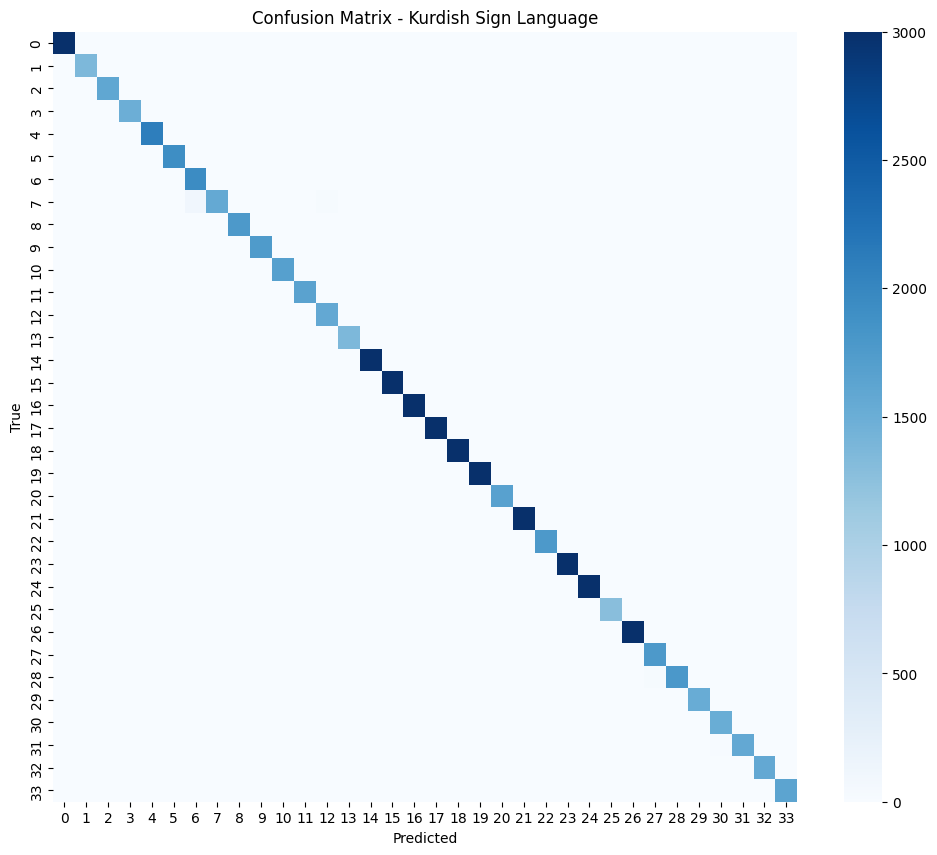

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - Kurdish Sign Language")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("/content/drive/MyDrive/Dataset/confusion_matrix.png")

plt.show()